In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Considering that
1. The price of the underlying asset follows a Geometric Brownian Motion.
2. There are no transaction costs or taxes.
3. The risk-free rate is constant.
4. The option can only be exercised at maturity (European style).
5. The market is efficient, meaning there are no arbitrage opportunities. 

C = Price of the call option

P = Price of the put option

S = Current price of the underlying asset

K = Strike price of the option

r = Risk-free interest rate

T = Time to maturity (in years)

σ =  Volatility

In [2]:
S = np.linspace(50, 150, 500)  
K = 100                        
T = 1.0                      
r = 0.05                     
sigma = 0.2     

N(x) = Cumulative distribution function of the standard normal distribution

d1 = (ln(S/K)+ (r+σ⋅σ/2)⋅T) / σ⋅√T

d2 =d1 − σ⋅√T

In [3]:
def d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

The Black-Scholes formula for a European call option is: 
**C=S⋅N(d1 )−K⋅exp(−rT)⋅N(d2)**

The Black-Scholes formula for a European put option is: 
**P=K⋅exp(−rT)⋅N(−d2 )−S⋅N(−d1 )**

Each Greek is a partial derivative of the Black-Scholes formula with respect to the variable of interest.

---
## DELTA

---

Delta is the rate of change of the option price with respect to changes in the underlying asset price (S). It represents the sensitivity of the option price to the price movements of the underlying asset.

**ΔCall=∂C/∂S = N(d1)**

**ΔPut=∂P/∂S ‎ = N(d1)-1**

In [4]:
def delta_call(S, K, T, r, sigma):
    return norm.cdf(d1(S, K, T, r, sigma))

def delta_put(S, K, T, r, sigma):
    return norm.cdf(d1(S, K, T, r, sigma)) - 1

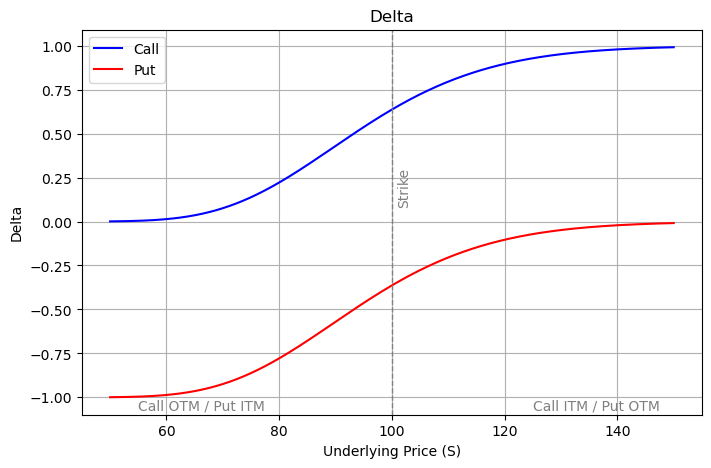

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(S, delta_call(S, K, T, r, sigma), label='Call', color='blue')
plt.plot(S, delta_put(S, K, T, r, sigma), label='Put', color='red')
plt.axvline(x=K, color='gray', linestyle='--', linewidth=1)
plt.text(K + 1, 0.1, 'Strike', rotation=90, color='gray')
plt.text(55, -1.07, 'Call OTM / Put ITM', color='gray')
plt.text(125, -1.07, 'Call ITM / Put OTM', color='gray')
plt.title("Delta")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Delta")
plt.grid(True)
plt.legend()
plt.show()

ΔCall rises smoothly from 0 (deep OTM) to 1 (deep ITM), whilst ΔPut falls smoothly from 0 (deep OTM) to –1 (deep ITM). At-the-money options are most sensitive to price movement. ITM options have the highest Delta, the ption price moves nearly dollar-for-dollar with the stock.

---
## GAMMA

---

Gamma is the rate of change of Delta with respect to changes in the underlying asset price. It measures how much Delta will change when the price of the underlying asset changes. 

**ΓCall=∂ΔCall/∂S‎ = N′(d1)/(S⋅σ⋅√T)**

**ΓPut=∂ΔPut/∂S‎ = N′(d1)/(S⋅σ⋅√T)**

Gamma is the same for the call option and the put option.

In [6]:
def gamma(S, K, T, r, sigma):
    return norm.pdf(d1(S, K, T, r, sigma)) / (S * sigma * np.sqrt(T))

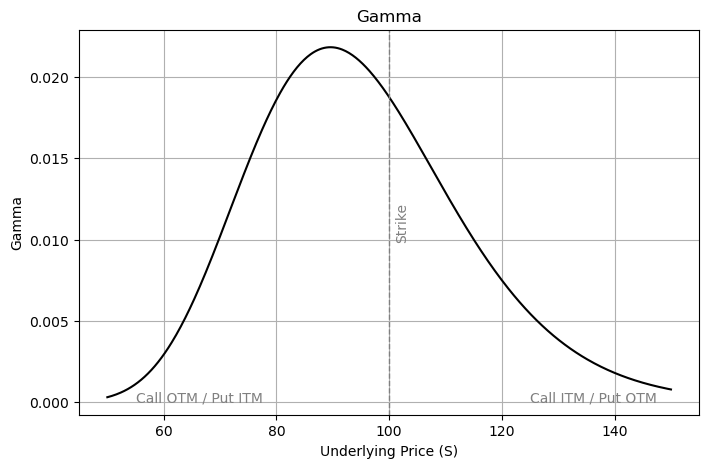

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(S, gamma(S, K, T, r, sigma), color='black')
plt.axvline(x=K, color='gray', linestyle='--', linewidth=1)
plt.text(K + 1, 0.01, 'Strike', rotation=90, color='gray')
plt.text(55, 0, 'Call OTM / Put ITM', color='gray')
plt.text(125, 0, 'Call ITM / Put OTM', color='gray')
plt.title("Gamma")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Gamma")
plt.grid(True)
plt.show()

Gamma peaks when the option is ATM and declines as it becomes deep ITM or OTM. Gamma is highest when there's uncertainty about whether the option will finish ITM or not. It measures how fast delta changes with S.

---
## VEGA

---

Vega is the sensitivity of the option price to changes in the volatility (σ) of the underlying asset.

**VCall=∂C/∂σ=S⋅N′(d1 )⋅√T**

**VPut=∂P/∂σ= S⋅N′(d1 )⋅√T**

Vega is the same for the call option and the put option

In [8]:
def vega(S, K, T, r, sigma):
    return S * norm.pdf(d1(S, K, T, r, sigma)) * np.sqrt(T)

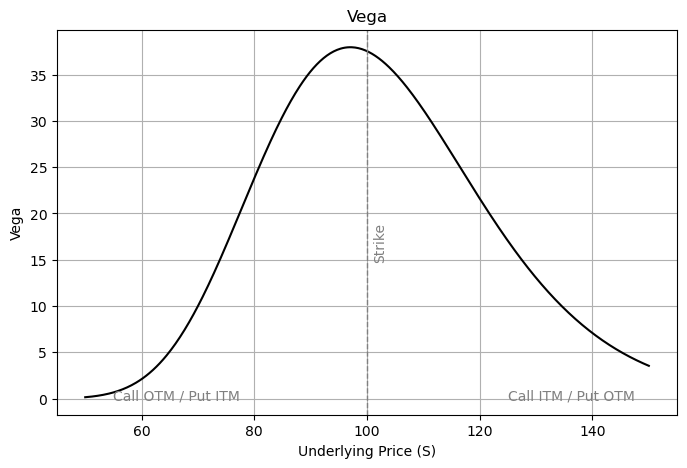

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(S, vega(S, K, T, r, sigma), color='black')
plt.axvline(x=K, color='gray', linestyle='--', linewidth=1)
plt.text(K + 1, 15, 'Strike', rotation=90, color='gray')
plt.text(55, -0.1, 'Call OTM / Put ITM', color='gray')
plt.text(125, -0.1, 'Call ITM / Put OTM', color='gray')
plt.title("Vega")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Vega")
plt.grid(True)
plt.show()

Vega peaks when the option is ATM and declines as it becomes deep ITM or OTM. Vega is highest when the option is ATM, because a small change in volatility significantly alters the likelihood of finishing ITM.

---
## THETA

---
Theta is the rate of change of the option price with respect to the time to maturity (T). Theta represents the time decay of the option value. If t is the current time.

**ΘCall = ∂C/∂t = - (S⋅N’(d1)⋅sigma) / (2⋅√T) - r⋅K⋅exp(-r⋅T)⋅N(d2)**

**ΘPut = ∂P/∂t = - (S⋅N’(d1)⋅sigma) / (2⋅√T) + r⋅K⋅exp(-r⋅T)⋅N(-d2)**

In [10]:
def theta_call(S, K, T, r, sigma):
    d1_val = d1(S, K, T, r, sigma)
    d2_val = d2(S, K, T, r, sigma)
    term1 = - (S * norm.pdf(d1_val) * sigma) / (2 * np.sqrt(T))
    term2 = - r * K * np.exp(-r * T) * norm.cdf(d2_val)
    return term1 + term2

def theta_put(S, K, T, r, sigma):
    d1_val = d1(S, K, T, r, sigma)
    d2_val = d2(S, K, T, r, sigma)
    term1 = - (S * norm.pdf(d1_val) * sigma) / (2 * np.sqrt(T))
    term2 = r * K * np.exp(-r * T) * norm.cdf(-d2_val)
    return term1 + term2

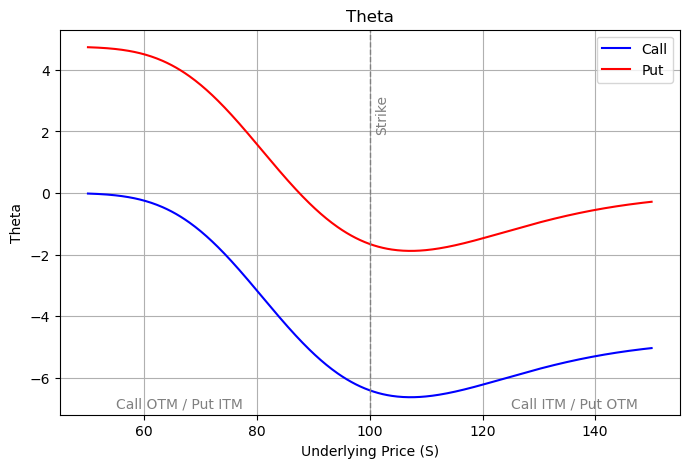

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(S, theta_call(S, K, T, r, sigma), label="Call", color="blue")
plt.plot(S, theta_put(S, K, T, r, sigma), label="Put", color="red")
plt.axvline(x=K, color='gray', linestyle='--', linewidth=1)
plt.text(K + 1, 2, 'Strike', rotation=90, color='gray')
plt.text(55, -7, 'Call OTM / Put ITM', color='gray')
plt.text(125, -7, 'Call ITM / Put OTM', color='gray')
plt.title("Theta")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Theta")
plt.grid(True)
plt.legend()
plt.show()

Both curves are lowest around the strike price. It is because an ATM option has the highest uncertainty about whether it will end up in-the-money or out-of-the-money. ATM options have high time value.
ITM options already have value locked in so there is little time value left. OTM options are unlikely to become profitable so there time value is also low.


---
## RHO

---
Rho measures the sensitivity of the option price to changes in the risk-free interest rate (r).

**ρCall = ∂C/∂r = K⋅T⋅exp(-r⋅T)⋅N(d2)**

**ρPut = ∂P/∂r = -K⋅T⋅exp(-r⋅T)⋅N(-d2)**

In [12]:
def rho_call(S, K, T, r, sigma):
    return K * T * np.exp(-r * T) * norm.cdf(d2(S, K, T, r, sigma))

def rho_put(S, K, T, r, sigma):
    return - K * T * np.exp(-r * T) * norm.cdf(-d2(S, K, T, r, sigma))

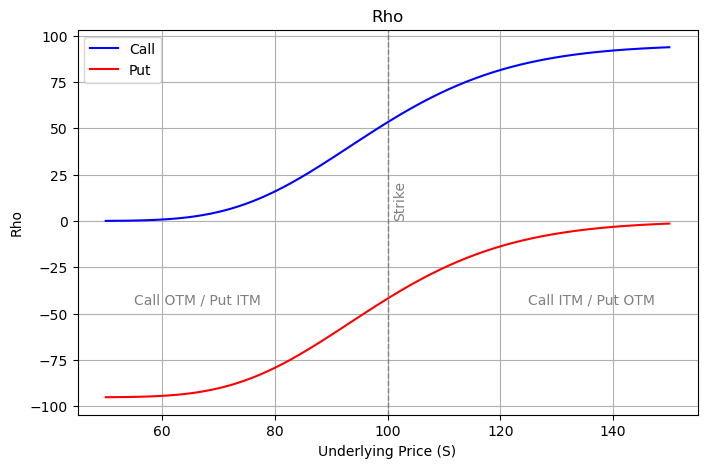

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(S, rho_call(S, K, T, r, sigma), label="Call", color="blue")
plt.plot(S, rho_put(S, K, T, r, sigma), label="Put", color="red")
plt.axvline(x=K, color='gray', linestyle='--', linewidth=1)
plt.text(K + 1, 2, 'Strike', rotation=90, color='gray')
plt.text(55, -45, 'Call OTM / Put ITM', color='gray')
plt.text(125, -45, 'Call ITM / Put OTM', color='gray')
plt.title("Rho")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Rho")
plt.grid(True)
plt.legend()
plt.show()

ρCall Rho is positive because rising interest rates increase call value. ρPut is negative because rising interest rates decrease put value. ρCall rises smoothly from 0 (deep OTM = little chance of payoff) to 100 (deep ITM = very sensitive to r), whilst ρPut falls smoothly from 0 (deep OTM = little chance of payoff) to –100 (deep ITM = very sensitive to r). Indeed, when ITM, as r increases, the present value of K decreases, so the call value increases and the put value decreases.